In [43]:
# base
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# pca
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA

# classification
from sklearn.model_selection import train_test_split
import jax.numpy as jnp
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    classification_report,
    f1_score,    
    f1_score,
    confusion_matrix,
    classification_report
)

# log reg
from jax.nn import softmax
from jax import grad
from sklearn.linear_model import LogisticRegression

# SVM
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# NN
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader



In [44]:
dunk = pd.read_csv('dunking-data.csv')
micro = pd.read_csv('microscopy-data.csv')

In [45]:
digestive_dunk = dunk[dunk['biscuit'] == 'Digestive']
hobnob_dunk = dunk[dunk['biscuit'] == 'Hobnob']
rich_dunk = dunk[dunk['biscuit'] == 'Rich Tea']

### PCA
Performing initial PCA

[0.36987929 0.2063917  0.20310831 0.19161252 0.02900817]


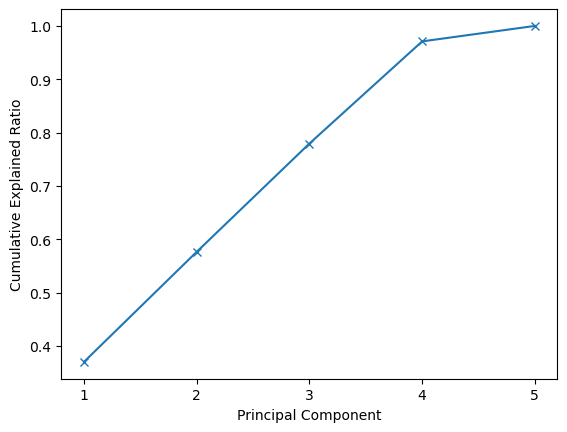

In [51]:
scaled_data = scale(dunk.drop(['biscuit'], axis = 1))

pca = PCA(n_components = 5)
pca.fit(scaled_data)

pca_5 = pca.fit_transform(scaled_data)

# See explained variances

fig,ax = plt.subplots()

print(pca.explained_variance_ratio_)

ax.plot(np.arange(1,6), np.cumsum(pca.explained_variance_ratio_), marker = 'x')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Ratio')
ax.set_xticks([1,2,3,4,5])

plt.show()

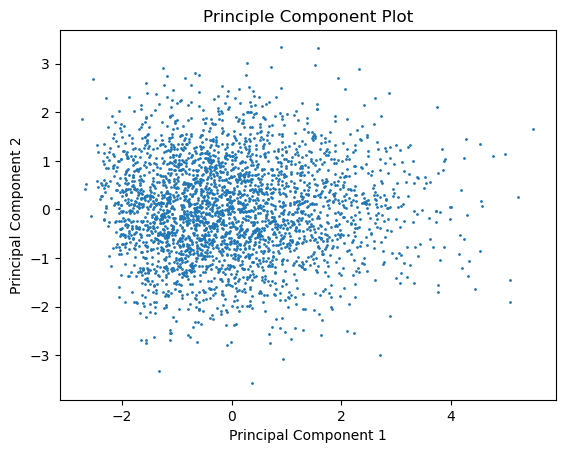

In [53]:
# Check for clustering in first two principal components

fig, ax = plt.subplots()

plt.scatter(pca_5[:,0], pca_5[:,1], s = 1)
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('Principle Component Plot')
plt.show()

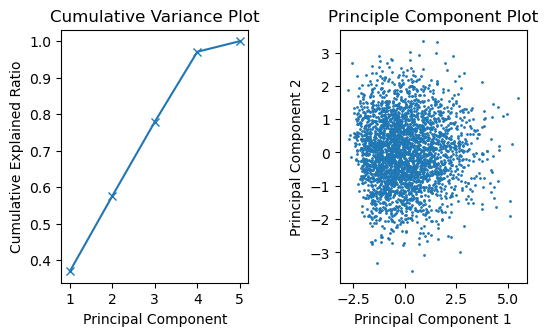

In [66]:
fig,ax =plt.subplots(1,2,figsize = (6,4))

ax[0].plot(np.arange(1,6), np.cumsum(pca.explained_variance_ratio_), marker = 'x')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Cumulative Explained Ratio')
ax[0].set_xticks([1,2,3,4,5])
ax[0].set_title('Cumulative Variance Plot')

ax[1].scatter(pca_5[:,0], pca_5[:,1], s = 1)
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')
ax[1].set_title('Principle Component Plot')

plt.tight_layout(pad=3.0)

plt.show()

so this highlights clearly why pca is not a good fit for the data. As many of the vars are dependent and are just experimental conditions, with L being the only true difference between the types

PCA reveals no clear clustering of biscuit types in the first two principal components, indicating that the dominant variance in the data does not align with class separation. This suggests that linear separation in low-dimensional projections is insufficient, motivating the use of supervised learning methods capable of capturing more complex decision boundaries.

# Classification

## data preparation

In [ ]:
dunk['encoded_label'] = [
    1 if i == 'Digestive' else 2 if i == 'Hobnob' else 0
    for i in dunk['biscuit'].values
]


feature_cols = ['gamma', 'phi', 'eta', 'L', 't']
X = dunk[feature_cols]
y = dunk['encoded_label']

In [ ]:
train, test = train_test_split(
    dunk,
    test_size=0.2,
    random_state=0,
    stratify=dunk['encoded_label']
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])
X_test = scaler.transform(test[feature_cols])

y_train = train['encoded_label'].values
y_test = test['encoded_label'].values




# X_train = jnp.array(X_train)
# X_test = jnp.array(X_test)
# y_train = jnp.array(y_train)
# y_test = jnp.array(y_test)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=0, stratify=y
# )

## M1: Logistic Regression

In [ ]:
n_features = X_train.shape[1]
num_classes = 3

weights = jnp.zeros((n_features, num_classes))
bias = jnp.zeros((num_classes,))

In [ ]:
num_classes = 3
y_train_onehot = jnp.eye(num_classes)[y_train]
y_test_onehot = jnp.eye(num_classes)[y_test]

In [ ]:
# Logistic regression on the scaled train/test split created in cell 10
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train, y_train)

pred_log_reg = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_log_reg))
print(confusion_matrix(y_test, pred_log_reg))
print(classification_report(y_test, pred_log_reg, target_names=['Rich Tea', 'Digestive', 'Hobnob']))

Accuracy: 0.7266666666666667
[[154   0  46]
 [  7 168  25]
 [ 52  34 114]]
              precision    recall  f1-score   support

    Rich Tea       0.72      0.77      0.75       200
   Digestive       0.83      0.84      0.84       200
      Hobnob       0.62      0.57      0.59       200

    accuracy                           0.73       600
   macro avg       0.72      0.73      0.72       600
weighted avg       0.72      0.73      0.72       600



## M2: SVM

In [ ]:
# Compare a couple of sklearn baselines on the same encoded-label split
methods = {
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

for name, model in methods.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} accuracy: {accuracy_score(y_test, y_pred):.3f}")
    print(f"{name} F1 (macro): {f1_score(y_test, y_pred, average='macro'):.3f}")
    print(confusion_matrix(y_test, y_pred))
    print()

SVM accuracy: 0.867
SVM F1 (macro): 0.867
[[184   0  16]
 [  3 183  14]
 [ 43   4 153]]

Random Forest accuracy: 0.832
Random Forest F1 (macro): 0.830
[[173   2  25]
 [  0 183  17]
 [ 30  27 143]]



## M3: Decision Tree

In [ ]:
def gini_impurity(labels):
    """
    Calculate the Gini impurity of a list of labels.
    
    :param y: a list of labels
    
    :return: the Gini impurity of the list
    """
    _, counts = np.unique(labels, return_counts=True)
    p = (counts / labels.size) ** 2
    return 1 - np.sum(p)

In [ ]:
def find_best_split(X, y):
    """
    Determines the best split for a dataset based
    on the Gini impurity.
    
    :param X: a 2D numpy array of features
    :param y: a 1D numpy array of labels
    
    :return: a tuple of the best feature, best threshold, and best gain
    """
    best_gain = 0
    best_feature = None
    best_threshold = None

    thresholds = np.unique(X, axis=0)
    for feature in range(X.shape[1]):
        for threshold in thresholds:
            y_left = y[np.where(X[:, feature] < threshold[feature])]
            y_right = y[np.where(X[:, feature] >= threshold[feature])]

            weight_left = y_left.size / y.size
            weight_right = y_right.size / y.size
            information_gain = gini_impurity(y) - (weight_left * gini_impurity(y_left) + weight_right * gini_impurity(y_right))

            if information_gain > best_gain:
                best_gain = information_gain
                best_feature = feature
                best_threshold = threshold[feature]

    return best_feature, best_threshold, best_gain

In [ ]:
X_np = X.to_numpy()
y_np = y.to_numpy() 
train_np = train.to_numpy()

find_best_split(X_np, y_np)

(3, np.float64(0.0074342641017306), np.float64(0.04281838741234156))

In [ ]:
def make_tree(X, y):
    """
    Recursively constructs a decision tree.
    
    :param X: a 2D numpy array of features
    :param y: a 1D numpy array of labels
    
    :returns: a dictionary representing the decision tree
    """
    if len(np.unique(y)) == 1:
        return np.argmax(np.bincount(y))
    
    feature, threshold, gain = find_best_split(X, y)

    if gain == 0:
        return np.argmax(np.bincount(y))

    left_X = X[np.where(X[:, feature] < threshold)]
    left_y = y[np.where(X[:, feature] < threshold)]
    right_X = X[np.where(X[:, feature] >= threshold)]
    right_y = y[np.where(X[:, feature] >= threshold)]

    left_subtree = make_tree(left_X, left_y)
    right_subtree = make_tree(right_X, right_y)

    return {"feature": feature,
            "threshold": threshold, 
            "gain": gain, 
            "left": left_subtree, 
            "right": right_subtree}

tree = make_tree(X_np, y_np)

In [ ]:
def traverse_tree(x, tree):
    """
    Traverse a decision tree to make a prediction.

    :param x: a 1D numpy array of features
    :param tree: a dictionary representing the decision tree

    :return: the prediction
    """
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]
    threshold = tree["threshold"]

    if x[feature] <= threshold:
        return traverse_tree(x, tree["left"])
    else:
        return traverse_tree(x, tree["right"])

# Example prediction on the first full-dataset row used to build the tree above
traverse_tree(X_np[0], tree)

np.int64(1)

## M4: Neural Network

In [ ]:
# X_train and X_test are already standardised in cell 10.
# Re-scaling them again here is unnecessary, so this cell is intentionally left as a note.

In [ ]:
# tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# dataloaders
batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(5, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
model = NeuralNetwork()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=3, bias=True)
  )
)


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_epoch(dataloader, model, loss_fn, optimiser):
    """Train the neural network for one epoch."""
    model.train()
    for X_batch, y_batch in dataloader:
        pred = model(X_batch)
        loss = loss_fn(pred, y_batch)

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

In [ ]:
def evaluate_model(dataloader, model, loss_fn):
    """Evaluate the neural network on a dataloader."""
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0.0, 0.0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            pred = model(X_batch)
            test_loss += loss_fn(pred, y_batch).item()
            correct += (pred.argmax(1) == y_batch).type(torch.float).sum().item()

    test_loss /= num_batches
    accuracy = correct / size
    print(f"Test Error:\n Accuracy: {(100 * accuracy):>0.1f}%, Avg loss: {test_loss:>8f}\n")
    return accuracy, test_loss

In [ ]:
epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_epoch(train_dataloader, model, loss_fn, optimiser)
    evaluate_model(test_dataloader, model, loss_fn)

print("Done!")

Epoch 1
-------------------------------
Test Error:
 Accuracy: 46.5%, Avg loss: 1.056351

Epoch 2
-------------------------------
Test Error:
 Accuracy: 54.5%, Avg loss: 0.974800

Epoch 3
-------------------------------
Test Error:
 Accuracy: 68.0%, Avg loss: 0.798552

Epoch 4
-------------------------------
Test Error:
 Accuracy: 76.7%, Avg loss: 0.646010

Epoch 5
-------------------------------
Test Error:
 Accuracy: 82.7%, Avg loss: 0.544311

Epoch 6
-------------------------------
Test Error:
 Accuracy: 85.5%, Avg loss: 0.472762

Epoch 7
-------------------------------
Test Error:
 Accuracy: 86.2%, Avg loss: 0.428494

Epoch 8
-------------------------------
Test Error:
 Accuracy: 88.2%, Avg loss: 0.387004

Epoch 9
-------------------------------
Test Error:
 Accuracy: 88.2%, Avg loss: 0.361388

Epoch 10
-------------------------------
Test Error:
 Accuracy: 87.8%, Avg loss: 0.343736

Epoch 11
-------------------------------
Test Error:
 Accuracy: 90.5%, Avg loss: 0.330268

Epoch 12

# Method Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import torch

# Use the single scaled split created in cell 10 for every comparison model
X_train_cmp = np.asarray(X_train)
X_test_cmp = np.asarray(X_test)
y_train_cmp = np.asarray(y_train)
y_test_cmp = np.asarray(y_test)

class_names = ['Rich Tea', 'Digestive', 'Hobnob']

print(f"Training rows: {len(y_train_cmp)}")
print(f"Test rows: {len(y_test_cmp)}")
print(f"Feature count: {X_train_cmp.shape[1]}")

Training rows: 2400
Test rows: 600
Feature count: 5


In [ ]:
# Train all comparison models and store their test-set predictions
predictions = {}
trained_models = {}

# 1. Logistic Regression
log_reg_cmp = LogisticRegression(max_iter=2000, random_state=42)
log_reg_cmp.fit(X_train_cmp, y_train_cmp)
predictions['Logistic Regression'] = log_reg_cmp.predict(X_test_cmp)
trained_models['Logistic Regression'] = log_reg_cmp

# 2. SVM
svm_cmp = SVC(random_state=42)
svm_cmp.fit(X_train_cmp, y_train_cmp)
predictions['SVM'] = svm_cmp.predict(X_test_cmp)
trained_models['SVM'] = svm_cmp

# 3. Random Forest
rf_cmp = RandomForestClassifier(random_state=42)
rf_cmp.fit(X_train_cmp, y_train_cmp)
predictions['Random Forest'] = rf_cmp.predict(X_test_cmp)
trained_models['Random Forest'] = rf_cmp

# 4. Custom Decision Tree
tree_cmp = make_tree(X_train_cmp, y_train_cmp)
predictions['Custom Decision Tree'] = np.array(
    [traverse_tree(x, tree_cmp) for x in X_test_cmp]
)
trained_models['Custom Decision Tree'] = tree_cmp

# 5. Neural Network
X_train_tensor_cmp = torch.tensor(X_train_cmp, dtype=torch.float32)
X_test_tensor_cmp = torch.tensor(X_test_cmp, dtype=torch.float32)
y_train_tensor_cmp = torch.tensor(y_train_cmp, dtype=torch.long)

train_dataset_cmp = TensorDataset(X_train_tensor_cmp, y_train_tensor_cmp)
train_loader_cmp = DataLoader(train_dataset_cmp, batch_size=32, shuffle=True)

nn_cmp = NeuralNetwork()
loss_fn_cmp = nn.CrossEntropyLoss()
optimiser_cmp = torch.optim.Adam(nn_cmp.parameters(), lr=1e-3)

epochs_cmp = 50
for epoch in range(epochs_cmp):
    nn_cmp.train()
    for X_batch, y_batch in train_loader_cmp:
        pred = nn_cmp(X_batch)
        loss = loss_fn_cmp(pred, y_batch)

        optimiser_cmp.zero_grad()
        loss.backward()
        optimiser_cmp.step()

nn_cmp.eval()
with torch.no_grad():
    predictions['Neural Network'] = nn_cmp(X_test_tensor_cmp).argmax(dim=1).cpu().numpy()

trained_models['Neural Network'] = nn_cmp

print(predictions.keys())

dict_keys(['Logistic Regression', 'SVM', 'Random Forest', 'Custom Decision Tree', 'Neural Network'])


In [ ]:
# Compare all models using the same multiclass metrics
summary_rows = []

for model_name, y_pred in predictions.items():
    summary_rows.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test_cmp, y_pred),
        'Macro Precision': precision_score(y_test_cmp, y_pred, average='macro', zero_division=0),
        'Macro Recall': recall_score(y_test_cmp, y_pred, average='macro', zero_division=0),
        'Macro F1': f1_score(y_test_cmp, y_pred, average='macro', zero_division=0)
    })

results_df = (
    pd.DataFrame(summary_rows)
    .reset_index(drop=True)
)

results_df

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.726667,0.723635,0.726667,0.724597
1,SVM,0.866667,0.871558,0.866667,0.866835
2,Random Forest,0.831667,0.829466,0.831667,0.829922
3,Custom Decision Tree,0.766667,0.766996,0.766667,0.766828
4,Neural Network,0.910000,0.909679,0.910000,0.909794


In [ ]:
# Confusion matrices and classification reports for each comparison model
for model_name, y_pred in predictions.items():
    print("=" * 70)
    print(model_name)
    print("-" * 70)
    print("Confusion matrix:")
    print(confusion_matrix(y_test_cmp, y_pred))
    print()
    print("Classification report:")
    print(classification_report(
        y_test_cmp,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))
    print()

Logistic Regression
----------------------------------------------------------------------
Confusion matrix:
[[154   0  46]
 [  7 168  25]
 [ 52  34 114]]

Classification report:
              precision    recall  f1-score   support

    Rich Tea       0.72      0.77      0.75       200
   Digestive       0.83      0.84      0.84       200
      Hobnob       0.62      0.57      0.59       200

    accuracy                           0.73       600
   macro avg       0.72      0.73      0.72       600
weighted avg       0.72      0.73      0.72       600


SVM
----------------------------------------------------------------------
Confusion matrix:
[[184   0  16]
 [  3 183  14]
 [ 43   4 153]]

Classification report:
              precision    recall  f1-score   support

    Rich Tea       0.80      0.92      0.86       200
   Digestive       0.98      0.92      0.95       200
      Hobnob       0.84      0.77      0.80       200

    accuracy                           0.87       600
   m

# Classification of MIcro
Now using the final version of the neural network with 91% accuracy I will attempt to classify the biscuits

In [ ]:
micro = pd.read_csv('microscopy-data.csv')

In [ ]:
feature_cols

['gamma', 'phi', 'eta', 'L', 't']

In [ ]:
reverse_label_map = {
    0: "Rich Tea",
    1: "Digestive",
    2: "Hobnob"
}

X_micro = micro[feature_cols].to_numpy()
X_micro_scaled = scaler.transform(X_micro)

X_micro_tensor = torch.tensor(X_micro_scaled, dtype=torch.float32)

nn_cmp.eval()
with torch.no_grad():
    logits = nn_cmp(X_micro_tensor)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    pred_idx = probs.argmax(axis=1)

micro["predicted_index"] = pred_idx
micro["predicted_biscuit"] = [reverse_label_map[i] for i in pred_idx]
micro["prediction_confidence"] = probs.max(axis=1)

for i in sorted(reverse_label_map.keys()):
    class_name = reverse_label_map[i].replace(" ", "_")
    micro[f"prob_{class_name}"] = probs[:, i]

micro.to_csv("micro_predicted.csv", index=False)

/home/wilfb/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
